# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: PolynomialEmbedding (n=3)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [138]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import jax
import jax.numpy as jnp
import numpy as np
import optax
import torch
import quimb.tensor as qtn
from sklearn.metrics import auc
from jax.nn.initializers import *
import matplotlib.pyplot as plt

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *



from cascaded_tn.training.cascaded_model import *
from cascaded_tn.builders.dimension_calculator import DimensionCalculator

In [139]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
print("JAX devices:", jax.devices())
print("JAX device kind:", jax.devices()[0].device_kind)
print("PyTorch CUDA:", torch.cuda.is_available())

JAX devices: [CudaDevice(id=0)]
JAX device kind: NVIDIA A100-SXM4-40GB
PyTorch CUDA: True


**Load 40 MHz dataset**

In [140]:
import utils.dataloader as d

inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #This should be false, otherwise there might be issues with reading the hdf5 files.
skip_MET_eta=False #Set this to True if you want to skip the MET eta feature in the dataset.
norm=True #Set this to True if you want to normalize the dataset features to zero mean and unit variance.
cartesian=False #Set this to True if you want to use cartesian coordinates (px, py, pz) instead of (pt, eta, phi).
normalize_tensors=False #Set to True if you want to normalize each particle tensor to unit norm.

FALSE


In [141]:
batch_size = 10000
background, background_val, background_test = d.create_split_dataloaders(
    file_path=inputPath+"background_for_training.h5",
    batch_size=batch_size,
    split_ratios=(0.85, 0.05, 0.10),
    norm=norm,
    skip_MET_eta=skip_MET_eta,
    cartesian=cartesian,
    shuffle=True,
    shuffle_before_split=False,
)
# background = d.load_data(inputPath + "background_for_training.h5", batch_size=batch_size, shuffle=True, skip_MET_eta=skip_MET_eta, norm=norm, cartesian=cartesian)

[DATASET SPLITS]
  Total samples: 4,000,000
  Train: 3,400,000 (85.0%)
  Val:   200,000 (5.0%)
  Test:  400,000 (10.0%)

[DATALOADERS CREATED]
  Train batches: 340
  Val batches:   20
  Test batches:  40


In [142]:
print("Background shape before:", next(iter(background)).shape)

Background shape before: torch.Size([10000, 57])


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [143]:
# define model parameters
# scale = 2.0
initializer = jax.nn.initializers.variance_scaling(scale=2.0, mode='fan_avg', distribution='uniform')
key = jax.random.PRNGKey(42)
target_loss = 50
huber_delta = 10
# k = 2
# embedding = PolynomialEmbedding(degree=k, n=1, include_bias=True)
# embedding = TrigonometricEmbedding(k)
# phys_dim = (embedding.dim, embedding.dim) # = (2k, 2k) for trigonometric embedding, (k+1, k+1) for polynomial embedding

embedding = ParticleVectorEmbedding(normalize=normalize_tensors)
add_identity = True
boundary='obc' # 'pbc' or 'obc' = periodic or open boundary conditions

In [144]:
def AsymmetricLogNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """Asymmetric loss combining log behavior for small norms and polynomial for large norms.
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data) # This is ||compressed||^4
    # For x < target_loss: log penalty prevents collapse
    # For x > target_loss: add quadratic growth for strong anomaly separation
    log_term = jax.lax.log(x/target_loss)
    symmetric_term = jax.lax.pow(log_term, 2)
    excess = jax.lax.max(0.0, x - target_loss)  # Only penalize when x > target_loss
    
    return symmetric_term + jax.lax.pow(excess, 2)

In [145]:
def SymmetricLogNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """Symmetric loss creating Gaussian-like distribution in log-space around target.
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data)  # ||compressed||^4 
    
    # Main loss: symmetric in log-space
    collapse_penalty = 1e-5 * jax.lax.pow(jax.lax.log(x/target_loss), 2)
    quadratic = jax.lax.pow(x - target_loss, 2)

    return quadratic + collapse_penalty

In [146]:
def LogHuberNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """Huber loss in log-space for robust symmetric training.
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data)
    error = x - target_loss
    abs_error = jax.lax.abs(error)

    # Huber threshold (tune this!)
    delta = huber_delta 
    
    # Quadratic for small errors, linear for large
    quadratic = 0.5 * jax.lax.pow(error, 2)
    linear = delta * (abs_error - 0.5 * delta)
    huber = jax.lax.select(abs_error <= delta, quadratic, linear)

    collapse_penalty = 1e-5 * jax.lax.pow(jax.lax.log(x/target_loss), 2)

    return huber + collapse_penalty

In [147]:
from cascaded_tn.training.regularization import LogAnomalyRegNorm

ChosenLossFunction = LogHuberNorm

alpha = 0.04
def loss_combined(*args, **kwargs):
    error = ChosenLossFunction
    # reg = lambda P: alpha * LogAnomalyRegNorm(
    #     P, 
    #     alpha_spectral=0.01,
    #     alpha_smooth=0.2,
    #     alpha_sparse=0
    # )
    reg = lambda P: 0.0
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [ ]:
autoencoder = create_trainable_autoencoder(
    layer_dims=[19,7,3],
    bond_dims=[7,2],
    phys_dims=[3,2,3],
    # enable_relu=[0],
    cyclic=False,
    symmetric=False,
    key=key,
    debug=False,
    initializer=initializer,
    add_identity=add_identity,
    boundary=boundary,
    optimizer=optax.adam,
    learning_rate=1e-3,
    loss_function=loss_combined,
)
# autoencoder = create_trainable_autoencoder(
#     layer_dims=[19,3],
#     bond_dims=[14],
#     phys_dims=[3,3],
#     # enable_relu=[0,1],
#     cyclic=False,
#     symmetric=False,
#     key=key,
#     debug=False,
#     initializer=initializer,
#     add_identity=add_identity,
#     boundary=boundary,
#     optimizer=optax.adam,
#     learning_rate=1e-3,
#     loss_function=loss_combined,
# )
autoencoder.device = 'gpu'

In [149]:
print("Number of parameters in the model are: ", autoencoder.nparams())

Number of parameters in the model are:  3398


In [150]:
def loss_fn(data, targets, *params):

    temp_model = autoencoder.copy()

    # Update with new parameters
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)

    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)

    # Apply the cascade (compression only for now)
    compressed = temp_model.cascade.apply(tn_i)
    
    return autoencoder.loss(compressed, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

In [151]:
# Split into two parts: data-dependent and model-dependent

@jax.jit
def compute_error_batch(sample_batch, *params):
    """JIT-compiled error computation for the batch"""
    def single_error(data_point, *p):
        # Create temp model and update params
        temp_model = autoencoder.copy()
        for tensor, param in zip(temp_model.tensors, p):
            tensor.modify(data=param)
        
        # Compute error for single point
        tn_i = embed(data_point, embedding)
        compressed = temp_model.cascade.apply(tn_i)
        return ChosenLossFunction(compressed, tn_i)
    
    # Vectorize over batch
    errors = jax.vmap(single_error, in_axes=[0] + [None]*len(params))(sample_batch, *params)
    return jnp.mean(errors)

# Separate function for regularization (computed ONCE, not per batch item!)
def compute_reg_components_fast(*params):
    """Compute regularization terms - only needs to run once per parameter update"""
    # Pre-compute tensor shapes and indices outside JIT
    tensor_shapes = [t.shape for t in autoencoder.tensors]
    layer_boundaries = []  # Store which tensors belong to which layer
    
    # Figure out tensor-to-layer mapping
    idx = 0
    for op in autoencoder.cascade.operators:
        if hasattr(op.implementation, 'tensors'):
            n_tensors = len(op.implementation.tensors)
            layer_boundaries.append((idx, idx + n_tensors))
            idx += n_tensors
    
    @jax.jit
    def reg_terms(params_concat):
        """JIT-compiled regularization computation"""
        # Split concatenated params back into individual tensors
        params_list = []
        start = 0
        for shape in tensor_shapes:
            size = np.prod(shape)
            param = params_concat[start:start+size].reshape(shape)
            params_list.append(param)
            start += size
        
        reg_spectral = reg_smooth = reg_sparse = 0.0
        prev_norm = None
        
        # Process each layer
        for layer_idx, (start_idx, end_idx) in enumerate(layer_boundaries):
            layer_tensors = params_list[start_idx:end_idx]
            
            # 1. Spectral regularization
            for tensor in layer_tensors:
                if len(tensor.shape) >= 2:
                    matrix = tensor.reshape(tensor.shape[0], -1)
                    s = jnp.linalg.svd(matrix, compute_uv=False)
                    effective_rank = jnp.sum(s) ** 2 / (jnp.sum(s ** 2))
                    reg_spectral += (1.0 / (effective_rank + 0.1))
            
            # 2. Layer smoothness
            curr_norm = sum(jnp.sum(t**2) for t in layer_tensors)
            if layer_idx > 0 and prev_norm is not None:
                reg_smooth += jnp.abs(jnp.log(curr_norm / (prev_norm)))
            prev_norm = curr_norm
            
            # 3. Bottleneck sparsity (last layer)
            if layer_idx == len(layer_boundaries) - 1:
                for tensor in layer_tensors:
                    reg_sparse += jnp.sum(jnp.abs(tensor))
        
        return reg_spectral, reg_smooth, reg_sparse
    
    # Concatenate all parameters into single array
    params_concat = jnp.concatenate([p.flatten() for p in params])
    
    return reg_terms(params_concat)

In [152]:
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+autoencoder.L)), in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

params = autoencoder.arrays
autoencoder.step, autoencoder.opt_state = autoencoder.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)

In [153]:
@jax.jit
def train_step_jitted(params, opt_state, batch):
    # Compute loss and gradients in one go
    loss_val, grads = jax.value_and_grad(
        lambda *p: jnp.mean(jax.vmap(loss_fn, in_axes=[0, None] + [None]*len(p))(batch, None, *p)),
        argnums=range(len(params))
    )(*params)
    
    # Update parameters
    grads_dict = {i: g for i, g in enumerate(grads)}
    params_dict = {i: p for i, p in enumerate(params)}
    
    updates, opt_state = autoencoder.optimizer.update(grads_dict, opt_state)
    params_dict = optax.apply_updates(params_dict, updates)
    
    return tuple(params_dict.values()), opt_state, loss_val

In [ ]:
from utils.training_tools import *
from tqdm import tqdm
import time

epochs = 150
history = { 'loss': [], 
            'val_error' : [],
            'spectral_term': [],
            'smooth_term': [],
            'sparse_term': [],
            'epoch_time': [], 
            'best_epoch': -1,
            'unfinished': True}

# Initialize early stopping
early_stopper = SimpleEarlyStopping(patience=10, min_delta=0.001)

print(f"[TRAINING] Starting training with early stopping (patience={early_stopper.patience}, min_delta={early_stopper.min_delta})")
print(f"[DATA] Train batches: {len(background)}, Val batches: {len(background_val)}")

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0

    for i, batch in enumerate(tqdm(background, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = autoencoder.arrays
        params, autoencoder.opt_state, loss = train_step_jitted(params, autoencoder.opt_state, batch)
        autoencoder.update_tensors(params)
        epoch_loss += loss
        # print(f"Batch {i+1}/{len(background)}: Loss = {loss:.6f}")
        # if i == 0:
        #     break # For debugging, only train on the first batch

    end_time = time.time()
    avg_loss = epoch_loss / len(background)

    # Compute individual loss terms for monitoring using the existing loss functions
    # Get current model parameters

    val_error = evaluate_validation_error(background_val, autoencoder, compute_error_batch)

    reg_spectral, reg_smooth, reg_sparse = compute_reg_components_fast(*autoencoder.arrays)
    reg_spectral = float(reg_spectral)
    reg_smooth = float(reg_smooth)
    reg_sparse = float(reg_sparse)

    history['loss'].append(avg_loss)
    history['val_error'].append(val_error)
    history['spectral_term'].append(reg_spectral)
    history['smooth_term'].append(reg_smooth)
    history['sparse_term'].append(reg_sparse)
    history['epoch_time'].append(end_time - start_time)
    
    # Print epoch summary
    print(f"[Epoch {epoch+1}] Train Loss: {avg_loss:.6f} | Val Error: {val_error:.6f} | "
          f"Spectral: {reg_spectral:.6f} | Smooth: {reg_smooth:.6f} | Sparse: {reg_sparse:.6f} | "
          f"Time: {end_time - start_time:.2f}s")
    
    # Early stopping check
    if early_stopper.check(val_error, autoencoder, epoch):
        print(f"[EARLY STOPPING] Training stopped at epoch {epoch + 1}")
        history['best_epoch'] = early_stopper.best_epoch
        
        # Restore best model
        early_stopper.restore_best_model(autoencoder)
        
        # Mark as finished (even though stopped early, it's a successful completion)
        history['unfinished'] = False
        break
    
    # If training completes all epochs
    if epoch == epochs - 1:
        history['unfinished'] = False
        history['best_epoch'] = early_stopper.best_epoch

# Final summary
print("\n" + "="*80)
print("[TRAINING COMPLETE]")
print(f"  Total epochs run: {len(history['loss'])}")
print(f"  Best epoch: {history['best_epoch'] + 1}")
print(f"  Best validation error: {early_stopper.best_loss:.6f}")
print(f"  Final validation error: {history['val_error'][-1]:.6f}")
print("="*80)

[TRAINING] Starting training with early stopping (patience=10, min_delta=0.001)
[DATA] Train batches: 340, Val batches: 20


Epoch 1/150:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 1/150: 100%|██████████| 340/340 [00:37<00:00,  8.96it/s]


[Epoch 1] Train Loss: 277.897576 | Val Error: 84.030589 | Spectral: 7.898596 | Smooth: 2.290387 | Sparse: 28.716916 | Time: 37.94s


Epoch 2/150: 100%|██████████| 340/340 [00:34<00:00,  9.72it/s]


...

Epoch 73/150: 100%|██████████| 340/340 [01:27<00:00,  3.89it/s]


[Epoch 73] Train Loss: 37.041664 | Val Error: 37.033323 | Spectral: 8.650315 | Smooth: 3.122815 | Sparse: 40.634055 | Time: 87.36s


Epoch 74/150: 100%|██████████| 340/340 [01:04<00:00,  5.25it/s]


[Epoch 74] Train Loss: 37.128698 | Val Error: 36.795728 | Spectral: 8.656685 | Smooth: 3.129505 | Sparse: 40.652728 | Time: 64.74s


Epoch 75/150:  45%|████▍     | 152/340 [00:45<00:36,  5.17it/s]

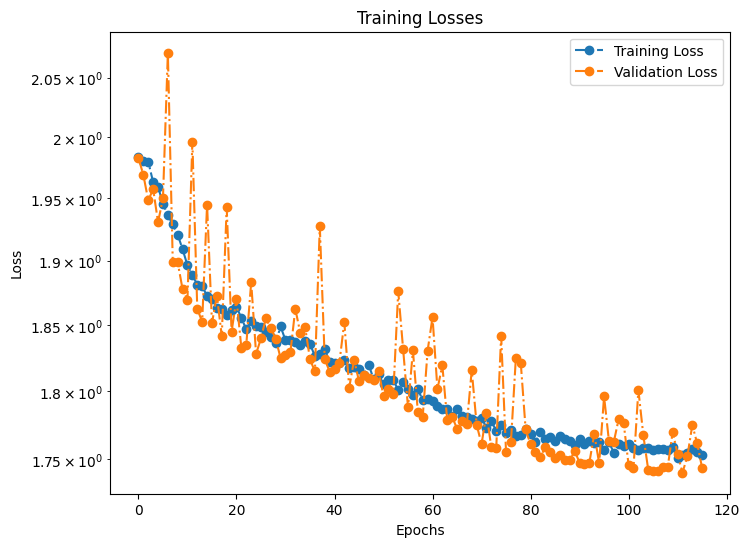

In [ ]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='Training Loss')
plt.plot(range(len(history['val_error'])), history['val_error'], linestyle="-.", marker='o', label='Validation Loss')
# plt.plot(range(len(history['spectral_term'])), history['spectral_term'], linestyle="-.", marker='o', label='Spectral Term')
# plt.plot(range(len(history['smooth_term'])), history['smooth_term'], linestyle="-.", marker='o', label='Smooth Term')
# plt.plot(range(len(history['sparse_term'])), history['sparse_term'], linestyle="-.", marker='o', label='Sparse Term')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.savefig('training_loss.png', dpi=300)

**Evaluate**

In [ ]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian)

In [ ]:
def InputsToNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """The norm itself
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data)
    return x

@jax.jit
def ComputeNorm(data, targets, *params):
    """Compute only the transformed norm"""
    # Create temp model with updated parameters
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    # Apply the cascade
    compressed = temp_model.cascade.apply(tn_i)
    
    # Return only error term (no regularization)
    return InputsToNorm(compressed, tn_i)

# Vectorize it for batch processing
norm_term = jax.jit(jax.vmap(ComputeNorm, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

In [ ]:
def InputsToScore(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """The anomaly score based on deviation from target norm.
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data)
    return jax.lax.abs(x - target_loss)

@jax.jit
def ComputeScore(data, targets, *params):
    """Compute the anomaly score"""
    # Create temp model with updated parameters
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    # Apply the cascade
    compressed = temp_model.cascade.apply(tn_i)
    
    # Return only error term (no regularization)
    return InputsToScore(compressed, tn_i)

# Vectorize it for batch processing
score_term = jax.jit(jax.vmap(ComputeScore, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

In [ ]:
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples

In [ ]:
# Run the evaluation on bkg and signals
bkg_norm = evaluate_model(autoencoder, background_test, norm_term, embedding, verbose=True)
a4l_norm = evaluate_model(autoencoder, a4l, norm_term, embedding, verbose=True)
lq_norm = evaluate_model(autoencoder, lq, norm_term, embedding, verbose=True)
htnu_norm = evaluate_model(autoencoder, htnu, norm_term, embedding, verbose=True)
htt_norm  = evaluate_model(autoencoder, htt, norm_term, embedding, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:11<00:00,  6.11it/s]


In [ ]:
# Run the evaluation on bkg and signals
bkg_score = evaluate_model(autoencoder, background_test, score_term, embedding, verbose=True)
a4l_score = evaluate_model(autoencoder, a4l, score_term, embedding, verbose=True)
lq_score = evaluate_model(autoencoder, lq, score_term, embedding, verbose=True)
htnu_score = evaluate_model(autoencoder, htnu, score_term, embedding, verbose=True)
htt_score  = evaluate_model(autoencoder, htt, score_term, embedding, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:09<00:00,  7.36it/s]


**Plot anomaly scores and ROC curve**

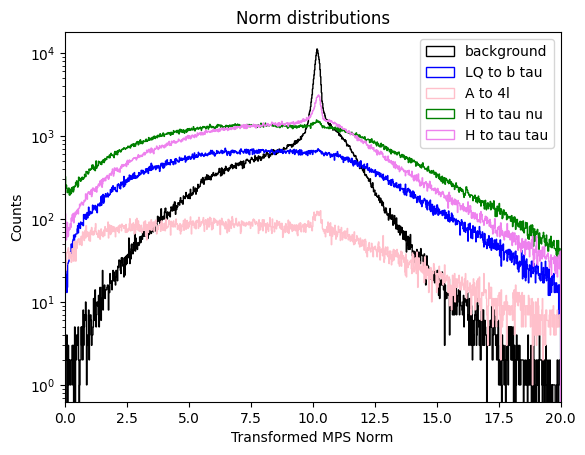

In [ ]:
plt.figure()
plt.yscale('log')
# plt.xscale('log')
# xmin = 1e-3
# xmax = 1e3
# bins = np.logspace(np.log(xmin), np.log(xmax), 1000)
xmin = 0
xmax = 20
bins = np.linspace(xmin, xmax, 1000)
plt.hist(bkg_norm, bins=bins, histtype='step', color='black', label='background')
plt.hist(lq_norm, bins=bins, histtype='step', color='blue', label='LQ to b tau')
plt.hist(a4l_norm, bins=bins, histtype='step', color='pink', label='A to 4l')
plt.hist(htnu_norm, bins=bins, histtype='step', color='green', label='H to tau nu')
plt.hist(htt_norm, bins=bins, histtype='step', color='violet', label='H to tau tau')
plt.title('Norm distributions')
plt.xlim([xmin, xmax])
# plt.xticks(np.arange(xmin, xmax+1, 1.0))
plt.xlabel('Transformed MPS Norm')
plt.ylabel('Counts')
plt.legend()
plt.savefig('transformed_norms.png', dpi=300)

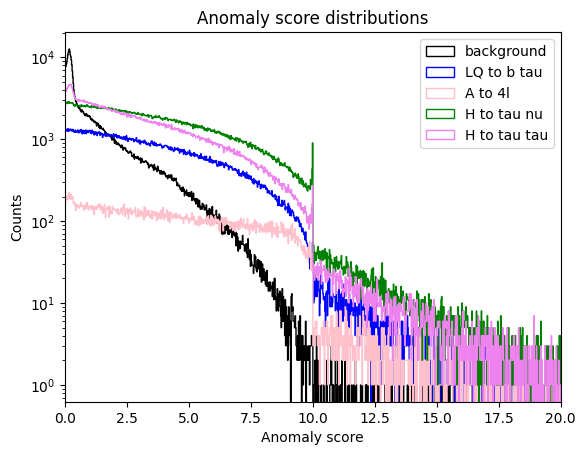

In [ ]:
plt.figure()
plt.yscale('log')
# plt.xscale('log')
# xmin = 1e-3
# xmax = 1e3
# bins = np.logspace(np.log(xmin), np.log(xmax), 1000)
xmin = 0
xmax = 20
bins = np.linspace(xmin, xmax, 1000)
plt.hist(bkg_score, bins=bins, histtype='step', color='black', label='background')
plt.hist(lq_score, bins=bins, histtype='step', color='blue', label='LQ to b tau')
plt.hist(a4l_score, bins=bins, histtype='step', color='pink', label='A to 4l')
plt.hist(htnu_score, bins=bins, histtype='step', color='green', label='H to tau nu')
plt.hist(htt_score, bins=bins, histtype='step', color='violet', label='H to tau tau')
plt.title('Anomaly score distributions')
plt.xlim([xmin, xmax])
# plt.xticks(np.arange(xmin, xmax+1, 1.0))
plt.xlabel('Anomaly score')
plt.ylabel('Counts')
plt.legend()
plt.savefig('anomaly_scores.png', dpi=300)

In [ ]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 19.715069330447157


In [ ]:
# Compute acceptance curves for each signal as a function of anomaly score threshold
thresholds = np.linspace(np.min(bkg_score), np.max(bkg_score), 1000)

def acceptance_curve(scores, thresholds):
   return np.array([(scores >= t).mean() for t in thresholds])

accept_lq = acceptance_curve(lq_score, thresholds)
accept_a4l = acceptance_curve(a4l_score, thresholds)
accept_htt = acceptance_curve(htt_score, thresholds)
accept_htnu = acceptance_curve(htnu_score, thresholds)

plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(thresholds, accept_lq * 100, color="blue", label="LQ to b tau")
plt.plot(thresholds, accept_a4l * 100, color="pink", label="A to 4l")
plt.plot(thresholds, accept_htnu * 100, color="green", label="H to tau nu")
plt.plot(thresholds, accept_htt * 100, color="violet", label="H to tau tau")
# Add horizontal lines and text for acceptance at score_threshold for each signal
for accept, label, color in [
   (accept_lq, "LQ to b tau", "blue"),
   (accept_a4l, "A to 4l", "pink"),
   (accept_htnu, "H to tau nu", "green"),
   (accept_htt, "H to tau tau", "violet"),
]:
   idx = np.searchsorted(thresholds, score_threshold, side="left")
   if idx >= len(accept):
      idx = -1
   acc_val = accept[idx] * 100
   plt.axhline(y=acc_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(thresholds[0], acc_val, f"{acc_val:.2f}%", color=color, va="bottom", fontsize=9)
plt.axvline(score_threshold, color='red', linestyle='--', label='FPR=1e-5 threshold')
plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Signal Acceptance (%)")
plt.title("Signal Acceptance vs Anomaly Score Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('signal_acceptance.png', dpi=300)

In [ ]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

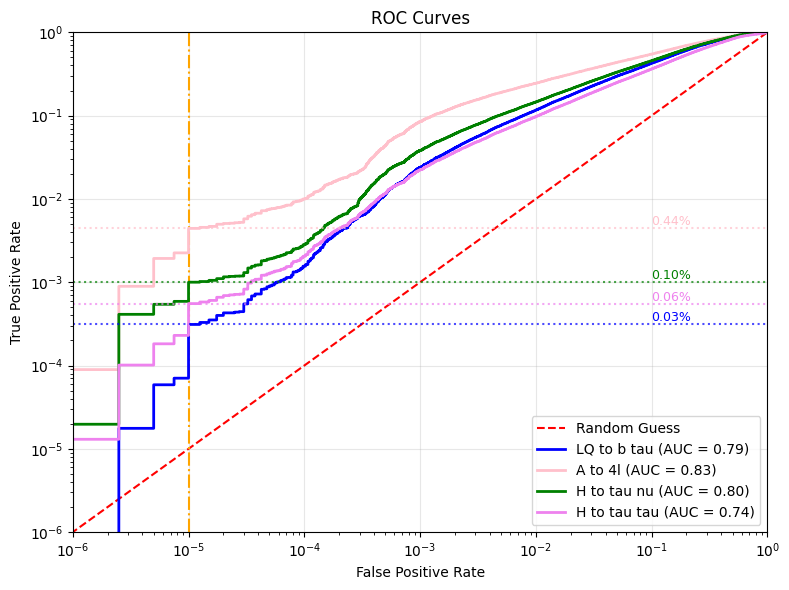

In [ ]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="right")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)

WINDOW-BASED ROC ANALYSIS

Background distribution:
  Min: 0.000001
  25%: 0.205275
  50%: 0.608164
  75%: 1.819577
  Max: 9142.650278
  Below 1.0: 60.16%
  Above 1.0: 39.84%

Signal: LQ to b tau
Signal distribution:
  Below 1.0: 18.54%
  Above 1.0: 81.46%

α = 0.05:
  Window at FPR≈1e-5: [-0.065599, 211.311978] (width=201.311978)
  Actual FPR: 2.50e-06
  TPR: 0.0012%
  AUC: 0.213
  Detected signals: 0 below -0.0656, 4 above 211.3120

α = 0.1:
  Window at FPR≈1e-5: [-0.174185, 111.741851] (width=101.741851)
  Actual FPR: 2.50e-06
  TPR: 0.0012%
  AUC: 0.212
  Detected signals: 0 below -0.1742, 4 above 111.7419

α = 0.3:
  Window at FPR≈1e-5: [-0.093015, 43.643383] (width=33.643383)
  Actual FPR: 5.00e-06
  TPR: 0.0026%
  AUC: 0.213
  Detected signals: 0 below -0.0930, 9 above 43.6434

α = 0.5:
  Window at FPR≈1e-5: [-0.036671, 30.073342] (width=20.073342)
  Actual FPR: 7.50e-06
  TPR: 0.0065%
  AUC: 0.213
  Detected signals: 0 below -0.0367, 22 above 30.0733

Best for LQ to b tau: α=0.

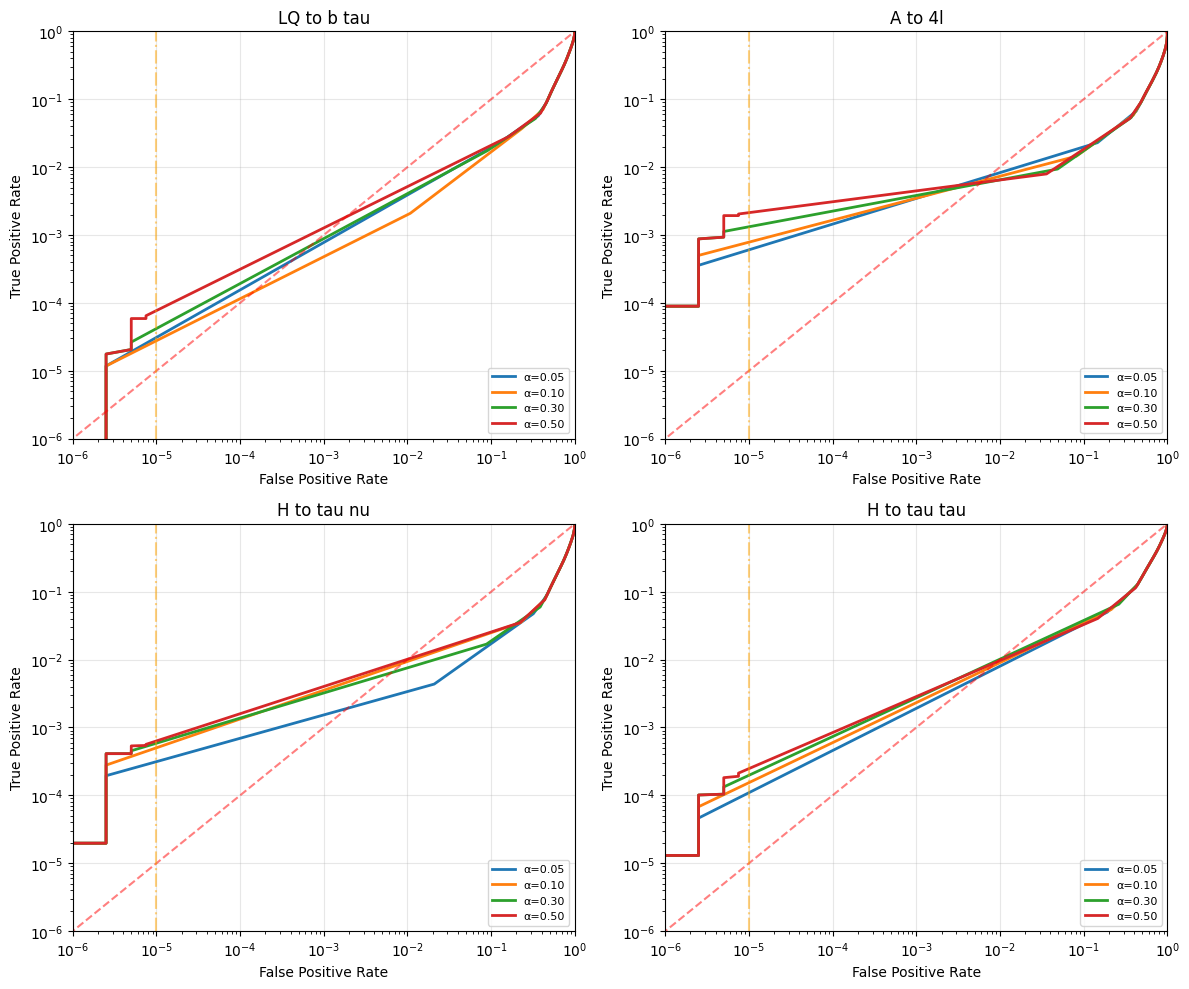


SUMMARY
LQ to b tau: Best α=0.5, TPR@FPR=1e-5=0.01%
A to 4l: Best α=0.5, TPR@FPR=1e-5=0.20%
H to tau nu: Best α=0.5, TPR@FPR=1e-5=0.06%
H to tau tau: Best α=0.5, TPR@FPR=1e-5=0.02%


In [ ]:
def get_window_roc_curve(bkg_score, sig_score, alpha=0.5, target=1.0, n_windows=1000):
    """
    Calculate ROC using window-based anomaly detection.
    Anomalous = outside [target - alpha*w, target + w]
    """
    # Scan window widths from very small to large
    max_deviation = max(np.max(np.abs(bkg_score - target)), 
                       np.max(np.abs(sig_score - target)))
    windows = np.logspace(-4, np.log10(max_deviation*1.1), n_windows)
    
    fpr_tpr_pairs = []
    
    for w in windows:
        lower = target - alpha * w
        upper = target + w
        
        # Count events outside window
        bkg_outside = (bkg_score < lower) | (bkg_score > upper)
        sig_outside = (sig_score < lower) | (sig_score > upper)
        
        fpr_val = np.mean(bkg_outside)
        tpr_val = np.mean(sig_outside)
        
        fpr_tpr_pairs.append((fpr_val, tpr_val, w, lower, upper))
    
    # Sort by FPR descending (from 1 to 0)
    fpr_tpr_pairs.sort(key=lambda x: -x[0])
    
    fpr = np.array([x[0] for x in fpr_tpr_pairs])
    tpr = np.array([x[1] for x in fpr_tpr_pairs])
    
    # Find window at FPR=1e-5
    target_fpr = 1e-5
    idx = np.searchsorted(-fpr, -target_fpr)  # negative because sorted descending
    if idx < len(fpr_tpr_pairs):
        w_at_target = fpr_tpr_pairs[idx][2]
        lower_at_target = fpr_tpr_pairs[idx][3]
        upper_at_target = fpr_tpr_pairs[idx][4]
        actual_fpr = fpr_tpr_pairs[idx][0]
        actual_tpr = fpr_tpr_pairs[idx][1]
    else:
        w_at_target = lower_at_target = upper_at_target = actual_fpr = actual_tpr = np.nan
    
    return fpr, tpr, (w_at_target, lower_at_target, upper_at_target, actual_fpr, actual_tpr)

# Main analysis with detailed output
def analyze_window_roc(bkg_score, signal_scores, signal_names, alphas=[0.05, 0.1, 0.3, 0.5]):
    """Analyze ROC with window approach and print diagnostics"""
    
    print("="*70)
    print("WINDOW-BASED ROC ANALYSIS")
    print("="*70)
    
    # First check background distribution
    print(f"\nBackground distribution:")
    print(f"  Min: {np.min(bkg_score):.6f}")
    print(f"  25%: {np.percentile(bkg_score, 25):.6f}")
    print(f"  50%: {np.percentile(bkg_score, 50):.6f}")
    print(f"  75%: {np.percentile(bkg_score, 75):.6f}")
    print(f"  Max: {np.max(bkg_score):.6f}")
    print(f"  Below 1.0: {np.mean(bkg_score < 1.0)*100:.2f}%")
    print(f"  Above 1.0: {np.mean(bkg_score > 1.0)*100:.2f}%")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    results_summary = {}
    
    for idx, (sig_score, sig_name, ax) in enumerate(zip(signal_scores, signal_names, axes)):
        print(f"\n{'='*50}")
        print(f"Signal: {sig_name}")
        print(f"{'='*50}")
        
        # Signal distribution
        print(f"Signal distribution:")
        print(f"  Below 1.0: {np.mean(sig_score < 1.0)*100:.2f}%")
        print(f"  Above 1.0: {np.mean(sig_score > 1.0)*100:.2f}%")
        
        best_tpr = 0
        best_alpha = None
        best_window_info = None
        
        for alpha in alphas:
            fpr, tpr, window_info = get_window_roc_curve(bkg_score, sig_score, alpha=alpha, target=target_loss)
            
            # Calculate AUC
            auc_val = auc(fpr, tpr)
            
            # Extract window info at FPR=1e-5
            w, lower, upper, actual_fpr, actual_tpr = window_info
            
            print(f"\nα = {alpha}:")
            print(f"  Window at FPR≈1e-5: [{lower:.6f}, {upper:.6f}] (width={w:.6f})")
            print(f"  Actual FPR: {actual_fpr:.2e}")
            print(f"  TPR: {actual_tpr*100:.4f}%")
            print(f"  AUC: {auc_val:.3f}")
            
            # Check where detected signals come from
            if not np.isnan(lower):
                sig_below_lower = np.sum(sig_score < lower)
                sig_above_upper = np.sum(sig_score > upper)
                print(f"  Detected signals: {sig_below_lower} below {lower:.4f}, {sig_above_upper} above {upper:.4f}")
            
            if actual_tpr > best_tpr:
                best_tpr = actual_tpr
                best_alpha = alpha
                best_window_info = (lower, upper, actual_fpr)
            
            # Plot ROC
            ax.plot(fpr, tpr, label=f'α={alpha:.2f}', linewidth=2)
        
        # Plot settings
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim([1e-6, 1.0])
        ax.set_ylim([1e-6, 1.0])
        ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
        ax.axvline(1e-5, color='orange', linestyle='-.', alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{sig_name}')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        print(f"\nBest for {sig_name}: α={best_alpha}, TPR={best_tpr*100:.4f}% at window [{best_window_info[0]:.4f}, {best_window_info[1]:.4f}]")
        results_summary[sig_name] = {'alpha': best_alpha, 'tpr': best_tpr*100}
    
    plt.tight_layout()
    plt.savefig('window_roc_analysis_detailed.png', dpi=300)
    plt.show()
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    for sig_name, res in results_summary.items():
        print(f"{sig_name}: Best α={res['alpha']}, TPR@FPR=1e-5={res['tpr']:.2f}%")
    
    return results_summary

# Run the analysis
results = analyze_window_roc(bkg_score, 
                            [lq_score, a4l_score, htnu_score, htt_score],
                            ['LQ to b tau', 'A to 4l', 'H to tau nu', 'H to tau tau'])

Background events: 400000 total
  Below 10: 163672 (40.92%)
  Above 10: 236328 (59.08%)

LQ to b tau events: 340544 total
  Below 10: 229819 (67.49%)
  Above 10: 110725 (32.51%)


  AUC: below=0.709, above=0.821, all=0.371
  TPR@FPR=1e-5: below=0.01%, above=0.02%, all=0.01%

A to 4l events: 55969 total
  Below 10: 39520 (70.61%)
  Above 10: 16449 (29.39%)
  AUC: below=0.777, above=0.829, all=0.329
  TPR@FPR=1e-5: below=0.06%, above=0.66%, all=0.23%

H to tau nu events: 760272 total
  Below 10: 504299 (66.33%)
  Above 10: 255973 (33.67%)
  AUC: below=0.727, above=0.832, all=0.377
  TPR@FPR=1e-5: below=0.09%, above=0.16%, all=0.06%

H to tau tau events: 691283 total
  Below 10: 445371 (64.43%)
  Above 10: 245912 (35.57%)
  AUC: below=0.676, above=0.758, all=0.390
  TPR@FPR=1e-5: below=0.03%, above=0.05%, all=0.02%



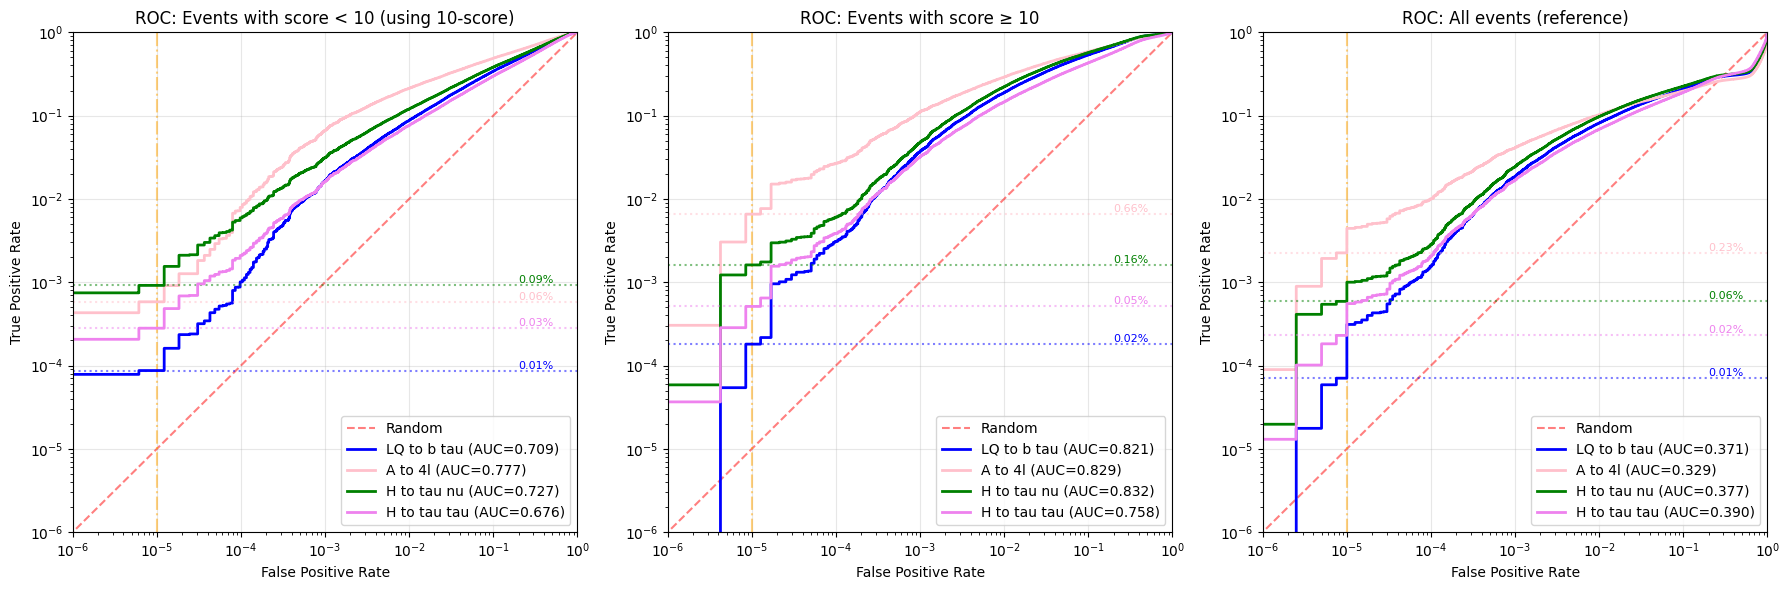

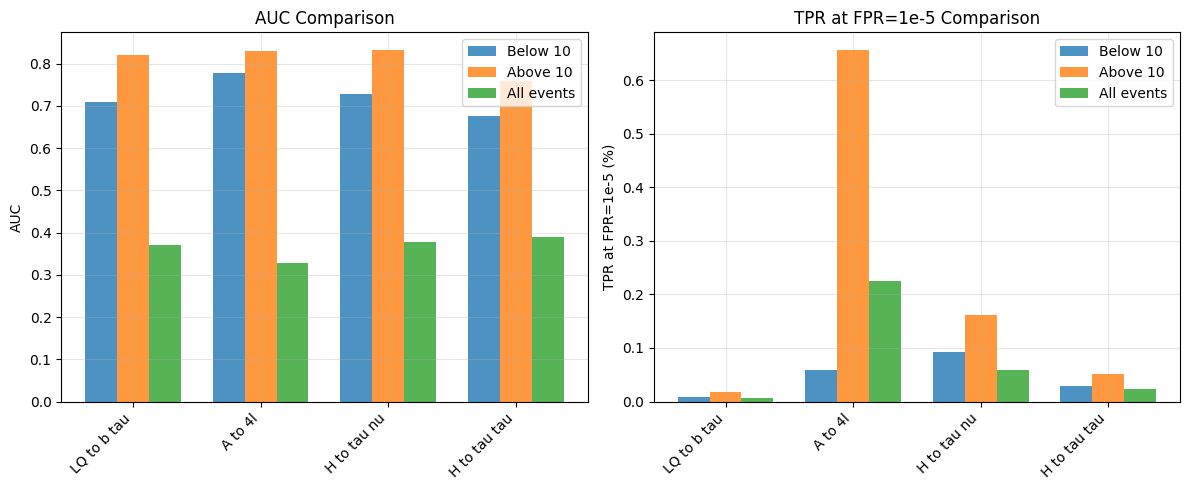

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# Split events based on 0.1 threshold
def split_by_threshold(scores, threshold=0.1):
    """Split scores into below and above threshold groups"""
    below_mask = scores < threshold
    above_mask = scores >= threshold
    return scores[below_mask], scores[above_mask], below_mask, above_mask

# Analyze ROC for each region
# Modified version - just replace the analyze_bimodal_roc function with this:
def analyze_bimodal_roc(bkg_score, signal_scores, signal_names, signal_colors, threshold=0.1):
    """
    Calculate and plot ROC curves for events below and above threshold
    For events below threshold, use inverted score (threshold - score)
    """
    
    # Split background
    bkg_below_mask = bkg_score < threshold
    bkg_above_mask = bkg_score >= threshold
    
    # CORRECTED: Invert scores for below-threshold events
    bkg_below = bkg_score[bkg_below_mask]
    bkg_below_corrected = threshold - bkg_below  # Now higher values = more anomalous
    bkg_above = bkg_score[bkg_above_mask]
    
    print(f"Background events: {len(bkg_score)} total")
    print(f"  Below {threshold}: {len(bkg_below)} ({100*len(bkg_below)/len(bkg_score):.2f}%)")
    print(f"  Above {threshold}: {len(bkg_above)} ({100*len(bkg_above)/len(bkg_score):.2f}%)")
    print()
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot settings
    for ax in axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim([1e-6, 1.0])
        ax.set_ylim([1e-6, 1.0])
        ax.plot([0, 1], [0, 1], color="red", linestyle="--", alpha=0.5, label="Random")
        ax.axvline(1e-5, color="orange", linestyle="-.", alpha=0.5)
        ax.grid(alpha=0.3)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
    
    axes[0].set_title(f"ROC: Events with score < {threshold} (using {threshold}-score)")
    axes[1].set_title(f"ROC: Events with score ≥ {threshold}")
    axes[2].set_title("ROC: All events (reference)")
    
    # Store results
    results = {}
    
    for sig_score, sig_name, sig_color in zip(signal_scores, signal_names, signal_colors):
        # Split signal
        sig_below_mask = sig_score < threshold
        sig_above_mask = sig_score >= threshold
        
        # CORRECTED: Invert scores for below-threshold events
        sig_below = sig_score[sig_below_mask]
        sig_below_corrected = threshold - sig_below  # Now higher values = more anomalous
        sig_above = sig_score[sig_above_mask]
        
        print(f"{sig_name} events: {len(sig_score)} total")
        print(f"  Below {threshold}: {len(sig_below)} ({100*len(sig_below)/len(sig_score):.2f}%)")
        print(f"  Above {threshold}: {len(sig_above)} ({100*len(sig_above)/len(sig_score):.2f}%)")
        
        # Calculate ROCs for each region
        roc_data = {}
        
        # Below threshold - using CORRECTED scores
        if len(bkg_below_corrected) > 0 and len(sig_below_corrected) > 0:
            fpr_below, tpr_below = get_roc_curve_data(bkg_below_corrected, sig_below_corrected, anomaly_det=True)
            auc_below = auc(fpr_below, tpr_below)
            axes[0].plot(fpr_below, tpr_below, color=sig_color, lw=2, 
                        label=f"{sig_name} (AUC={auc_below:.3f})")
            
            # Find TPR at FPR=1e-5
            idx = np.searchsorted(fpr_below, 1e-5, side="left")
            if idx < len(tpr_below):
                tpr_at_1e5_below = tpr_below[idx]
                axes[0].axhline(y=tpr_at_1e5_below, xmin=0, xmax=1, 
                               color=sig_color, linestyle=":", alpha=0.5)
                axes[0].text(2e-1, tpr_at_1e5_below, f"{tpr_at_1e5_below*100:.2f}%", 
                            color=sig_color, va="bottom", fontsize=8)
            else:
                tpr_at_1e5_below = np.nan
            
            roc_data['below'] = {'auc': auc_below, 'tpr_at_1e5': tpr_at_1e5_below}
        else:
            roc_data['below'] = {'auc': np.nan, 'tpr_at_1e5': np.nan}
        
        # Above threshold - no change needed
        if len(bkg_above) > 0 and len(sig_above) > 0:
            fpr_above, tpr_above = get_roc_curve_data(bkg_above, sig_above, anomaly_det=True)
            auc_above = auc(fpr_above, tpr_above)
            axes[1].plot(fpr_above, tpr_above, color=sig_color, lw=2, 
                        label=f"{sig_name} (AUC={auc_above:.3f})")
            
            # Find TPR at FPR=1e-5
            idx = np.searchsorted(fpr_above, 1e-5, side="left")
            if idx < len(tpr_above):
                tpr_at_1e5_above = tpr_above[idx]
                axes[1].axhline(y=tpr_at_1e5_above, xmin=0, xmax=1, 
                               color=sig_color, linestyle=":", alpha=0.5)
                axes[1].text(2e-1, tpr_at_1e5_above, f"{tpr_at_1e5_above*100:.2f}%", 
                            color=sig_color, va="bottom", fontsize=8)
            else:
                tpr_at_1e5_above = np.nan
            
            roc_data['above'] = {'auc': auc_above, 'tpr_at_1e5': tpr_at_1e5_above}
        else:
            roc_data['above'] = {'auc': np.nan, 'tpr_at_1e5': np.nan}
        
        # All events (still using original scores as reference)
        fpr_all, tpr_all = get_roc_curve_data(bkg_score, sig_score, anomaly_det=True)
        auc_all = auc(fpr_all, tpr_all)
        axes[2].plot(fpr_all, tpr_all, color=sig_color, lw=2, 
                    label=f"{sig_name} (AUC={auc_all:.3f})")
        
        idx = np.searchsorted(fpr_all, 1e-5, side="left")
        if idx < len(tpr_all):
            tpr_at_1e5_all = tpr_all[idx]
            axes[2].axhline(y=tpr_at_1e5_all, xmin=0, xmax=1, 
                           color=sig_color, linestyle=":", alpha=0.5)
            axes[2].text(2e-1, tpr_at_1e5_all, f"{tpr_at_1e5_all*100:.2f}%", 
                        color=sig_color, va="bottom", fontsize=8)
        else:
            tpr_at_1e5_all = np.nan
        
        roc_data['all'] = {'auc': auc_all, 'tpr_at_1e5': tpr_at_1e5_all}
        results[sig_name] = roc_data
        
        print(f"  AUC: below={roc_data['below']['auc']:.3f}, "
              f"above={roc_data['above']['auc']:.3f}, "
              f"all={roc_data['all']['auc']:.3f}")
        print(f"  TPR@FPR=1e-5: below={roc_data['below']['tpr_at_1e5']*100:.2f}%, "
              f"above={roc_data['above']['tpr_at_1e5']*100:.2f}%, "
              f"all={roc_data['all']['tpr_at_1e5']*100:.2f}%")
        print()
    
    for ax in axes:
        ax.legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig('roc_bimodal_analysis_corrected.png', dpi=300)
    plt.show()
    
    return results

# Also create a summary comparison plot
def plot_performance_comparison(results):
    """Create bar plots comparing performance metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    signals = list(results.keys())
    x = np.arange(len(signals))
    width = 0.25
    
    # AUC comparison
    auc_below = [results[s]['below']['auc'] for s in signals]
    auc_above = [results[s]['above']['auc'] for s in signals]
    auc_all = [results[s]['all']['auc'] for s in signals]
    
    axes[0].bar(x - width, auc_below, width, label=f'Below {target_loss}', alpha=0.8)
    axes[0].bar(x, auc_above, width, label=f'Above {target_loss}', alpha=0.8)
    axes[0].bar(x + width, auc_all, width, label='All events', alpha=0.8)
    axes[0].set_ylabel('AUC')
    axes[0].set_title('AUC Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(signals, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # TPR at FPR=1e-5 comparison
    tpr_below = [results[s]['below']['tpr_at_1e5']*100 for s in signals]
    tpr_above = [results[s]['above']['tpr_at_1e5']*100 for s in signals]
    tpr_all = [results[s]['all']['tpr_at_1e5']*100 for s in signals]
    
    axes[1].bar(x - width, tpr_below, width, label=f'Below {target_loss}', alpha=0.8)
    axes[1].bar(x, tpr_above, width, label=f'Above {target_loss}', alpha=0.8)
    axes[1].bar(x + width, tpr_all, width, label='All events', alpha=0.8)
    axes[1].set_ylabel('TPR at FPR=1e-5 (%)')
    axes[1].set_title('TPR at FPR=1e-5 Comparison')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(signals, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('performance_comparison_bimodal.png', dpi=300)
    plt.show()

# Run the analysis
signal_norms = [lq_norm, a4l_norm, htnu_norm, htt_norm]
signal_names = ['LQ to b tau', 'A to 4l', 'H to tau nu', 'H to tau tau']
signal_colors = ['blue', 'pink', 'green', 'violet']

results = analyze_bimodal_roc(bkg_norm, signal_norms, signal_names, signal_colors, threshold=target_loss)
plot_performance_comparison(results)

In [ ]:
def unified_anomaly_score(scores, threshold=0.1):
    """
    Create a unified score that properly handles both modes:
    - Below threshold: use (threshold - score) 
    - Above threshold: use (score - threshold)
    This gives distance from 0.1 in both directions
    """
    return np.abs(scores - threshold)

def weighted_unified_score(scores, threshold=0.1, below_weight=0.5):
    """
    Weighted version that can emphasize the better-performing region
    """
    below_mask = scores < threshold
    
    # Create unified score
    unified = np.zeros_like(scores)
    
    # Below threshold: distance from threshold (weighted)
    unified[below_mask] = below_weight * (threshold - scores[below_mask])
    
    # Above threshold: distance from threshold  
    unified[~below_mask] = scores[~below_mask] - threshold
    
    return unified

# Test different scoring strategies
def compare_scoring_strategies(bkg_score, signal_scores, signal_names):
    strategies = {
        'Original (norm)': lambda s: s,
        'Absolute distance': lambda s: np.abs(s - target_loss),
        'Squared distance': lambda s: (s - target_loss)**2,
        'Above only': lambda s: np.maximum(0, s - target_loss),
        'Weighted (below=0.5)': lambda s: weighted_unified_score(s, threshold=target_loss, below_weight=0.5),
        'Weighted (below=0.3)': lambda s: weighted_unified_score(s, threshold=target_loss, below_weight=0.3),
    }
    
    results = []
    
    for strategy_name, strategy_func in strategies.items():
        bkg_transformed = strategy_func(bkg_score)
        
        strategy_results = {'Strategy': strategy_name}
        
        for sig_score, sig_name in zip(signal_scores, signal_names):
            sig_transformed = strategy_func(sig_score)
            
            # Calculate ROC
            fpr, tpr = get_roc_curve_data(bkg_transformed, sig_transformed, anomaly_det=True)
            auc_val = auc(fpr, tpr)
            
            # Find TPR at FPR=1e-5
            idx = np.searchsorted(fpr, 1e-5, side="left")
            tpr_at_1e5 = tpr[idx] if idx < len(tpr) else 0
            
            strategy_results[f'{sig_name}_AUC'] = auc_val
            strategy_results[f'{sig_name}_TPR'] = tpr_at_1e5
        
        results.append(strategy_results)
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    for idx, (sig_name, ax) in enumerate(zip(signal_names, axes.flat)):
        # Extract data for this signal
        strategies_list = [r['Strategy'] for r in results]
        tpr_values = [r[f'{sig_name}_TPR'] * 100 for r in results]
        auc_values = [r[f'{sig_name}_AUC'] for r in results]
        
        # Create bar plot
        x = np.arange(len(strategies_list))
        width = 0.35
        
        ax2 = ax.twinx()
        
        bars1 = ax.bar(x - width/2, tpr_values, width, label='TPR at FPR=1e-5 (%)', color='blue', alpha=0.7)
        bars2 = ax2.bar(x + width/2, auc_values, width, label='AUC', color='orange', alpha=0.7)
        
        ax.set_xlabel('Strategy')
        ax.set_ylabel('TPR at FPR=1e-5 (%)', color='blue')
        ax2.set_ylabel('AUC', color='orange')
        ax.set_title(f'{sig_name}')
        ax.set_xticks(x)
        ax.set_xticklabels(strategies_list, rotation=45, ha='right')
        ax.tick_params(axis='y', labelcolor='blue')
        ax2.tick_params(axis='y', labelcolor='orange')
        
        # Add value labels on bars
        for bar, val in zip(bars1, tpr_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        
        for bar, val in zip(bars2, auc_values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('scoring_strategy_comparison.png', dpi=300)
    plt.show()
    
    return results

# Run comparison
results = compare_scoring_strategies(bkg_score, signal_scores, signal_names)

In [ ]:
def analyze_extreme_tails(bkg_score, signal_scores, signal_names):
    """Analyze what scores correspond to different FPR thresholds"""
    
    # Find thresholds for different FPR values
    fprs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # For each scoring strategy
    strategies = {
        'Original': lambda s: s,
        'Abs distance': lambda s: np.abs(s - target_loss),
        'Above only': lambda s: np.maximum(0, s - target_loss),
    }
    
    for idx, (sig_score, sig_name, ax) in enumerate(zip(signal_scores, signal_names, axes.flat)):
        
        thresholds_data = []
        
        for strategy_name, strategy_func in strategies.items():
            bkg_transformed = strategy_func(bkg_score)
            sig_transformed = strategy_func(sig_score)
            
            # Sort background scores descending
            sorted_bkg = np.sort(bkg_transformed)[::-1]
            
            thresholds = []
            for fpr in fprs:
                idx_fpr = int(fpr * len(sorted_bkg))
                if idx_fpr < len(sorted_bkg):
                    threshold = sorted_bkg[idx_fpr]
                else:
                    threshold = sorted_bkg[0]
                thresholds.append(threshold)
                
                # Calculate signal efficiency at this threshold
                sig_eff = np.mean(sig_transformed > threshold) * 100
                
            thresholds_data.append((strategy_name, thresholds))
            
        # Plot thresholds
        x = np.arange(len(fprs))
        width = 0.25
        
        for i, (strategy_name, thresholds) in enumerate(thresholds_data):
            ax.bar(x + i*width, thresholds, width, label=strategy_name)
        
        ax.set_xlabel('FPR')
        ax.set_ylabel('Score threshold')
        ax.set_title(f'{sig_name}')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f'1e-{int(-np.log10(f))}' for f in fprs])
        ax.set_yscale('log')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('threshold_analysis.png', dpi=300)
    plt.show()

# Check the actual distribution of extreme events
def examine_extreme_events(bkg_score, signal_scores, signal_names, threshold=0.1):
    """Look at the most anomalous events in detail"""
    
    print("="*60)
    print("EXTREME BACKGROUND EVENTS (top 0.001% most anomalous)")
    print("="*60)
    
    # Get top 0.001% most anomalous background
    n_extreme = max(1, int(0.00001 * len(bkg_score)))  # FPR=1e-5
    
    # For different scoring methods
    strategies = {
        'Original': lambda s: s,
        'Abs distance': lambda s: np.abs(s - target_loss),
        'Above only': lambda s: np.maximum(0, s - target_loss),
    }
    
    for strategy_name, strategy_func in strategies.items():
        bkg_transformed = strategy_func(bkg_score)
        
        # Get indices of most anomalous
        top_indices = np.argsort(bkg_transformed)[-n_extreme:]
        top_scores_original = bkg_score[top_indices]
        top_scores_transformed = bkg_transformed[top_indices]
        
        print(f"\n{strategy_name} strategy:")
        print(f"  Number of extreme events: {n_extreme}")
        print(f"  Original scores range: [{top_scores_original.min():.4f}, {top_scores_original.max():.4f}]")
        print(f"  Transformed scores range: [{top_scores_transformed.min():.4f}, {top_scores_transformed.max():.4f}]")
        print(f"  How many from <{target_loss}: {np.sum(top_scores_original < target_loss)}")
        print(f"  How many from >{target_loss}: {np.sum(top_scores_original > target_loss)}")
        
    print("\n" + "="*60)
    print("SIGNAL DETECTION AT FPR=1e-5")
    print("="*60)
    
    for sig_score, sig_name in zip(signal_scores, signal_names):
        print(f"\n{sig_name}:")
        for strategy_name, strategy_func in strategies.items():
            bkg_transformed = strategy_func(bkg_score)
            sig_transformed = strategy_func(sig_score)
            
            # Find threshold at FPR=1e-5
            sorted_bkg = np.sort(bkg_transformed)[::-1]
            idx_fpr = int(1e-5 * len(sorted_bkg))
            threshold_score = sorted_bkg[idx_fpr] if idx_fpr < len(sorted_bkg) else sorted_bkg[0]
            
            # How many signals pass this threshold
            n_sig_pass = np.sum(sig_transformed > threshold_score)
            tpr = n_sig_pass / len(sig_transformed)
            
            # Of those that pass, where did they come from?
            sig_passing_mask = sig_transformed > threshold_score
            sig_passing_original = sig_score[sig_passing_mask]
            
            print(f"  {strategy_name}:")
            print(f"    Threshold: {threshold_score:.4f}")
            print(f"    TPR: {tpr*100:.3f}%")
            if n_sig_pass > 0:
                print(f"    Passing signals from <{target_loss}: {np.sum(sig_passing_original < target_loss)}")
                print(f"    Passing signals from >{target_loss}: {np.sum(sig_passing_original > target_loss)}")

# Run analyses
analyze_extreme_tails(bkg_score, signal_scores, signal_names)
examine_extreme_events(bkg_score, signal_scores, signal_names)

In [ ]:
def dump_model_trace(model, data_event, embedding, output_file="model_trace.json"):
    """
    Dump complete model execution trace to JSON with all weights and clear structure.
    
    Args:
        model: Your trained autoencoder model
        data_event: Single input event (shape: [56])
        embedding: The embedding object (TrigonometricEmbedding)
        output_file: Output JSON filename
    """
    import json
    import numpy as np
    import jax.numpy as jnp
    from tn4ml.embeddings import embed
    import os
    
    # Convert torch tensor to numpy if needed
    if hasattr(data_event, 'cpu'):  # It's a torch tensor
        data_event = data_event.cpu().numpy()
    elif hasattr(data_event, '__array__'):  # It's a JAX array
        data_event = np.array(data_event)
    
    print(f"Dumping trace for input shape {data_event.shape}...")
    
    # Get cascade
    cascade = model.cascade
    
    # Get actual architecture
    layer_dims = [cascade.operators[0].config.input_dim]
    layer_dims.extend([op.config.output_dim for op in cascade.operators])
    
    # Initialize trace
    trace = {
        "architecture": " → ".join(str(d) for d in layer_dims),
        "input_raw": {
            "shape": list(data_event.shape),
            "values": data_event.tolist()
        },
        "layers": [],
        "intermediate_outputs": []
    }
    
    # Step 1: Embed input
    data_jax = jnp.array(data_event)
    input_mps = embed(data_jax, embedding)
    
    # Store embedded input
    embedded = {
        "description": f"MPS representation of embedded input (56 sites, phys_dim={embedding.dim})",
        "num_tensors": len(input_mps.tensors),
        "tensors": []
    }
    
    for i, tensor in enumerate(input_mps.tensors):
        data_array = np.array(tensor.data)
        tensor_info = {
            "tensor_idx": i,
            "shape": list(tensor.shape),
            "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
        }
        
        # Format values based on tensor structure
        if len(data_array.shape) == 2:  # Edge tensor [bond, phys]
            tensor_info["values"] = {
                "format": "[bond, phys]",
                "data": [data_array[b, :].tolist() for b in range(data_array.shape[0])]
            }
        elif len(data_array.shape) == 3:  # Middle tensor [left_bond, right_bond, phys]
            tensor_info["values"] = {
                "format": "[left_bond, right_bond, phys]",
                "data": []
            }
            for l in range(data_array.shape[0]):
                bond_slice = []
                for r in range(data_array.shape[1]):
                    bond_slice.append(data_array[l, r, :].tolist())
                tensor_info["values"]["data"].append(bond_slice)
        else:
            tensor_info["values"] = data_array.tolist()
        
        embedded["tensors"].append(tensor_info)
    
    trace["input_embedded"] = embedded
    
    # Step 2: Go through each layer
    current_mps = input_mps
    
    for layer_idx, operator in enumerate(cascade.operators):
        print(f"  Processing layer {layer_idx}: {operator.config.input_dim} → {operator.config.output_dim}")
        
        # Store layer info and ALL weights
        layer_info = {
            "index": layer_idx,
            "type": operator.operation_type if hasattr(operator, 'operation_type') else 'unknown',
            "dims": f"{operator.config.input_dim} → {operator.config.output_dim}",
            "bond_dim": operator.config.bond_dim,
            "weights": []
        }
        
        # Get tensors from operator
        if hasattr(operator, 'implementation') and hasattr(operator.implementation, 'tensors'):
            tensors = operator.implementation.tensors
        elif hasattr(operator, 'tensors'):
            tensors = operator.tensors
        else:
            tensors = []
        
        # Store ALL weights with clear formatting
        for t_idx, tensor in enumerate(tensors):
            weight_data = np.array(tensor.data)
            weight_info = {
                "tensor_idx": t_idx,
                "shape": list(weight_data.shape),
                "size": weight_data.size,
                "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
            }
            
            # Format based on tensor type
            if len(weight_data.shape) == 3:  # [bond, phys_up, phys_down]
                weight_info["format"] = "[bond, phys_up, phys_down]"
                weight_info["values"] = []
                for b in range(weight_data.shape[0]):
                    weight_info["values"].append({
                        "bond_idx": b,
                        "phys_matrix": weight_data[b, :, :].tolist()
                    })
            elif len(weight_data.shape) == 4:  # [left_bond, right_bond, phys_up, phys_down]
                weight_info["format"] = "[left_bond, right_bond, phys_up, phys_down]"
                if weight_data.size < 1000:  # Full data for small tensors
                    weight_info["values"] = []
                    for l in range(weight_data.shape[0]):
                        left_slice = []
                        for r in range(weight_data.shape[1]):
                            left_slice.append({
                                "indices": f"[{l},{r},:,:]",
                                "phys_matrix": weight_data[l, r, :, :].tolist()
                            })
                        weight_info["values"].append(left_slice)
                else:  # Truncate for large tensors
                    weight_info["values"] = {
                        "truncated": True,
                        "showing": "corners only",
                        "top_left": weight_data[0, 0, :, :].tolist(),
                        "stats": {
                            "min": float(weight_data.min()),
                            "max": float(weight_data.max()),
                            "mean": float(weight_data.mean()),
                            "std": float(weight_data.std())
                        }
                    }
            else:
                # Fallback for other shapes
                if weight_data.size < 200:
                    weight_info["values"] = weight_data.tolist()
                else:
                    weight_info["values"] = {
                        "truncated": True,
                        "first_100": weight_data.flatten()[:100].tolist(),
                        "shape_original": list(weight_data.shape)
                    }
            
            layer_info["weights"].append(weight_info)
        
        trace["layers"].append(layer_info)
        
        # Apply operator and store result
        output_mps = operator.apply(current_mps)
        
        # Store intermediate output
        intermediate = {
            "after_layer": layer_idx,
            "output_dim": operator.config.output_dim,
            "num_mps_tensors": len(output_mps.tensors),
            "mps_tensors": []
        }
        
        for i, tensor in enumerate(output_mps.tensors):
            data = np.array(tensor.data)
            tensor_data = {
                "tensor_idx": i,
                "shape": list(data.shape),
                "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
                "norm": float(np.linalg.norm(data)),
            }
            
            # Format values clearly
            if len(data.shape) == 2 and data.size < 500:
                tensor_data["values"] = {
                    "format": f"[{data.shape[0]}, {data.shape[1]}]",
                    "data": data.tolist()
                }
            elif len(data.shape) == 3 and data.size < 500:
                tensor_data["values"] = {
                    "format": f"[{data.shape[0]}, {data.shape[1]}, {data.shape[2]}]",
                    "data": []
                }
                for i in range(data.shape[0]):
                    tensor_data["values"]["data"].append(data[i, :, :].tolist())
            else:
                # For large tensors, show sample
                tensor_data["values"] = {
                    "size": data.size,
                    "first_50_flat": data.flatten()[:50].tolist()
                }
            
            intermediate["mps_tensors"].append(tensor_data)
        
        trace["intermediate_outputs"].append(intermediate)
        current_mps = output_mps
    
    # Step 3: Final output (contracted)
    final_contracted = current_mps.contract(all, optimize='auto-hq')
    final_output = np.array(final_contracted.data if hasattr(final_contracted, 'data') else final_contracted)
    
    trace["output_final"] = {
        "shape": list(final_output.shape),
        "values": final_output.flatten().tolist()
    }
    
    # Add summary
    trace["summary"] = {
        "architecture": layer_dims,
        "num_layers": len(cascade.operators),
        "total_weight_tensors": sum(len(layer["weights"]) for layer in trace["layers"]),
        "total_parameters": sum(sum(w["size"] for w in layer["weights"]) for layer in trace["layers"])
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(trace, f, indent=2)
    
    print(f"✅ Trace saved to {output_file}")
    print(f"   Architecture: {trace['architecture']}")
    print(f"   Total parameters: {trace['summary']['total_parameters']:,}")
    print(f"   File size: {os.path.getsize(output_file) / 1024:.2f} KB")
    
    return trace


# Usage:
test_event = next(iter(background))[0]
trace = dump_model_trace(autoencoder, test_event, embedding, "model_trace.json")

In [ ]:
"""
Test script to analyze SVD compression behavior on intermediate MPS tensors.
This helps determine optimal bond dimensions for the cascade.
"""

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tn4ml.embeddings import embed, TrigonometricEmbedding
import quimb.tensor as qtn


def analyze_mps_singular_values(mps, site_idx=None):
    """
    Analyze singular value distribution in an MPS.
    
    Args:
        mps: The MPS to analyze
        site_idx: Specific site to analyze (None = all sites)
    
    Returns:
        Dictionary with singular value information
    """
    results = {}
    
    if site_idx is not None:
        sites = [site_idx]
    else:
        sites = range(len(mps.tensors) - 1)
    
    for i in sites:
        # Get the tensor and reshape for SVD
        if i == 0:
            # First tensor: (right_bond, phys)
            tensor = mps.tensors[i].data
            matrix = tensor.reshape(-1, tensor.shape[-1])
        elif i == len(mps.tensors) - 1:
            # Last tensor: (left_bond, phys)
            continue
        else:
            # Middle tensor: (left_bond, right_bond, phys)
            tensor = mps.tensors[i].data
            # Reshape to (left_bond * phys, right_bond)
            matrix = tensor.reshape(tensor.shape[0] * tensor.shape[-1], tensor.shape[1])
        
        # Compute SVD
        U, S, Vh = jnp.linalg.svd(matrix, full_matrices=False)
        
        results[f'site_{i}'] = {
            'singular_values': np.array(S),
            'bond_dim_original': len(S),
            'matrix_shape': matrix.shape,
            'cumulative_sum': np.cumsum(S) / np.sum(S),  # Cumulative importance
            'effective_rank': np.sum(S)**2 / np.sum(S**2)  # Participation ratio
        }
    
    return results


def test_compression_levels(model, test_input, embedding, layer_idx=2, bond_dims=[4, 8, 16, 32, 64, 128]):
    """
    Test different compression levels on a specific layer's output.
    
    Args:
        model: Your trained autoencoder
        test_input: Single test input
        embedding: Embedding to use
        layer_idx: Which layer's output to analyze (0, 1, or 2)
        bond_dims: List of max bond dimensions to test
    
    Returns:
        Dictionary with compression test results
    """
    print(f"Testing compression on layer {layer_idx} output...")
    
    # Get cascade
    cascade = model.cascade
    
    # Convert input
    if hasattr(test_input, 'cpu'):
        test_input = test_input.cpu().numpy()
    test_input = jnp.array(test_input)
    
    # Process through cascade up to specified layer
    current_mps = embed(test_input, embedding)
    
    for i in range(layer_idx + 1):
        print(f"\nProcessing layer {i}...")
        current_mps = cascade.operators[i].apply(current_mps)
        print(f"Output MPS: {len(current_mps.tensors)} tensors")
        
        # Check bond dimensions
        bonds = []
        for j in range(len(current_mps.tensors) - 1):
            if j < len(current_mps.tensors[j].shape) - 1:
                bonds.append(current_mps.tensors[j].shape[1] if len(current_mps.tensors[j].shape) > 2 else current_mps.tensors[j].shape[0])
        print(f"Bond dimensions: {bonds}")
    
    # Analyze singular values BEFORE compression
    print(f"\nAnalyzing singular values after layer {layer_idx}...")
    sv_analysis = analyze_mps_singular_values(current_mps)
    
    # Store original for comparison
    original_mps = current_mps.copy()
    original_norm = original_mps.norm()
    
    # Test different compression levels
    compression_results = {
        'original_bond_dims': bonds,
        'singular_value_analysis': sv_analysis,
        'compression_tests': {}
    }
    
    for max_bond in bond_dims:
        print(f"\nTesting compression with max_bond={max_bond}...")
        
        # Compress
        compressed_mps = original_mps.copy()
        compressed_mps.compress(max_bond=max_bond, cutoff=1e-12)
        
        # Measure difference
        diff_norm = (original_mps - compressed_mps).norm()
        relative_error = diff_norm / original_norm
        
        # Get compressed bond dimensions
        compressed_bonds = []
        for j in range(len(compressed_mps.tensors) - 1):
            if j < len(compressed_mps.tensors[j].shape) - 1:
                compressed_bonds.append(compressed_mps.tensors[j].shape[1] if len(compressed_mps.tensors[j].shape) > 2 else compressed_mps.tensors[j].shape[0])
        
        # Contract both to compare final outputs
        original_contracted = original_mps.contract(all, optimize='auto-hq')
        compressed_contracted = compressed_mps.contract(all, optimize='auto-hq')
        
        output_diff = jnp.linalg.norm(original_contracted.data - compressed_contracted.data)
        output_relative_error = output_diff / jnp.linalg.norm(original_contracted.data)
        
        compression_results['compression_tests'][max_bond] = {
            'compressed_bonds': compressed_bonds,
            'relative_error_mps': float(relative_error),
            'relative_error_output': float(output_relative_error),
            'compression_ratio': bonds[0] / max_bond if bonds else 1.0
        }
        
        print(f"  Compressed bonds: {compressed_bonds}")
        print(f"  MPS relative error: {relative_error:.2e}")
        print(f"  Output relative error: {output_relative_error:.2e}")
    
    return compression_results, original_mps


def plot_singular_value_analysis(results, save_path="singular_values_analysis.png"):
    """
    Plot singular value decay and cumulative importance.
    """
    sv_analysis = results['singular_value_analysis']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Singular Value Analysis of Intermediate MPS', fontsize=16)
    
    # Plot 1: Singular value decay for first few sites
    ax = axes[0, 0]
    for i, (site, data) in enumerate(list(sv_analysis.items())[:3]):
        sv = data['singular_values']
        ax.semilogy(sv, 'o-', label=f'{site} (dim={len(sv)})', alpha=0.7)
    ax.set_xlabel('Index')
    ax.set_ylabel('Singular Value')
    ax.set_title('Singular Value Decay (log scale)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative importance
    ax = axes[0, 1]
    for i, (site, data) in enumerate(list(sv_analysis.items())[:3]):
        cumsum = data['cumulative_sum']
        ax.plot(cumsum, '-', label=f'{site}', linewidth=2)
        # Mark 99% and 99.9% thresholds
        idx_99 = np.argmax(cumsum >= 0.99)
        idx_999 = np.argmax(cumsum >= 0.999)
        ax.axvline(idx_99, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(idx_999, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Number of Singular Values')
    ax.set_ylabel('Cumulative Importance')
    ax.set_title('Cumulative Singular Value Importance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Compression error vs bond dimension
    ax = axes[1, 0]
    compression_tests = results['compression_tests']
    bond_dims = sorted(compression_tests.keys())
    mps_errors = [compression_tests[d]['relative_error_mps'] for d in bond_dims]
    output_errors = [compression_tests[d]['relative_error_output'] for d in bond_dims]
    
    ax.semilogy(bond_dims, mps_errors, 'o-', label='MPS Error', linewidth=2)
    ax.semilogy(bond_dims, output_errors, 's-', label='Output Error', linewidth=2)
    ax.set_xlabel('Max Bond Dimension')
    ax.set_ylabel('Relative Error')
    ax.set_title('Compression Error vs Bond Dimension')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Effective rank distribution
    ax = axes[1, 1]
    effective_ranks = [data['effective_rank'] for data in sv_analysis.values()]
    sites = list(range(len(effective_ranks)))
    ax.bar(sites, effective_ranks, alpha=0.7)
    ax.set_xlabel('Site Index')
    ax.set_ylabel('Effective Rank')
    ax.set_title('Effective Rank by Site')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("COMPRESSION ANALYSIS SUMMARY")
    print("="*60)
    
    # Find optimal compression
    for site, data in list(sv_analysis.items())[:1]:  # Just show first site
        sv = data['singular_values']
        cumsum = data['cumulative_sum']
        
        print(f"\n{site}:")
        print(f"  Original bond dimension: {len(sv)}")
        print(f"  Effective rank: {data['effective_rank']:.2f}")
        print(f"  SV range: [{sv[0]:.3f}, {sv[-1]:.2e}]")
        print(f"  To keep 99% info: {np.argmax(cumsum >= 0.99) + 1} dimensions")
        print(f"  To keep 99.9% info: {np.argmax(cumsum >= 0.999) + 1} dimensions")
        print(f"  To keep 99.99% info: {np.argmax(cumsum >= 0.9999) + 1} dimensions")
    
    print("\nCompression recommendations:")
    for max_bond, data in compression_tests.items():
        if data['relative_error_output'] < 1e-6:
            print(f"  Max bond = {max_bond}: Output error = {data['relative_error_output']:.2e} ✓")
            break


# Example usage function
def run_compression_test(model, test_event=None, embedding=None):
    """
    Run the complete compression test on your model.
    
    Args:
        model: Your trained CascadedModel
        test_event: Test input (if None, uses random)
        embedding: Embedding (if None, uses TrigonometricEmbedding)
    """
    # Setup defaults
    if test_event is None:
        input_dim = model.cascade.operators[0].config.input_dim
        test_event = np.random.randn(input_dim)
        print(f"Using random input of dimension {input_dim}")
    
    if embedding is None:
        embedding = TrigonometricEmbedding(k=1)
    
    # Test each layer
    all_results = {}
    
    for layer_idx in range(2):  # Test layers 0, 1
        print(f"\n{'='*60}")
        print(f"TESTING LAYER {layer_idx}")
        print(f"{'='*60}")
        
        results, mps = test_compression_levels(
            model, 
            test_event, 
            embedding,
            layer_idx=layer_idx,
            bond_dims=[2, 4, 6, 8]
        )
        
        all_results[f'layer_{layer_idx}'] = results
        
        # Plot for this layer
        plot_singular_value_analysis(
            results, 
            save_path=f"compression_analysis_layer_{layer_idx}.png"
        )
    
    # Overall recommendation
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    for layer_idx in range(2):
        results = all_results[f'layer_{layer_idx}']
        original_bond = results['original_bond_dims'][0] if results['original_bond_dims'] else 'N/A'
        
        # Find minimal bond dim with acceptable error
        min_bond = None
        for bond_dim in sorted(results['compression_tests'].keys()):
            if results['compression_tests'][bond_dim]['relative_error_output'] < 1e-6:
                min_bond = bond_dim
                break
        
        print(f"\nLayer {layer_idx}:")
        print(f"  Current bond dim: {original_bond}")
        print(f"  Recommended max bond: {min_bond or 'No compression needed'}")
        if min_bond and original_bond != 'N/A':
            print(f"  Compression factor: {original_bond/min_bond:.2f}x")
    
    return all_results

test_event = next(iter(background))[0]
results = run_compression_test(autoencoder, test_event, embedding)